# ORC1 Fiber Assay Analysis

**Purpose:** Compare replication speed and inter-origin distance between WT and MGS variants.

**Author:** Elena Lopatukhina
**Date:** 2026-07-14

## Workflow
1. Libraries import
2. Parameters import
3. Data loading
4. Data propcessing
5. Basic statistics calculation
6. Processing outliers
7. Statistical analysis
8. Tables export

# 1. Libraries import

In [37]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind
import warnings

# 2. Parameters

In [ ]:
INPUT_DIR = "/mnt/c/users/helen/Desktop/test"
OUTPUT_DIR = "/mnt/c/users/helen/Desktop/test"

pixel_size = 0.16125 # µm
conversion_factor = 2.59 # kb/µm
time = 20 # minutes

# 3. Import data

## 3.1 Data loading

In [8]:
dfs = []
all_dirs = []

for root, dirs, files in os.walk(INPUT_DIR):
    all_dirs.append(dirs)
    
    for filename in files:
        if filename.lower().endswith(".csv"):

            path = os.path.join(root, filename)
            df = pd.read_csv(path)
            
            # If everything ended up in one column, try semicolon
            if df.shape[1] == 1:
                df = pd.read_csv(path, sep=";")

            # Optional metadata
            df["File"] = os.path.splitext(filename)[0].replace(" ", "_")
            df["Path"] = path

            dfs.append(df) 

# Combine all tables
data = pd.concat(dfs, ignore_index=True)

# Convert Length in pixels into micrometers
data['Length'] = data['Length'].apply(lambda x: x * pixel_size)

# Create ROI column
data['ROI'] = data['Label'].apply(lambda x: x.split(":")[1])

# Create Sample name column empty (custom parsing of filenames)
data['Sample_name'] = None

# Delete first 3 columns
data.drop(data.columns[[0, 1, 2]], axis=1, inplace=True)

# Reorder columns
data = data[
    [
        "Sample_name",
        "File",
        "Measurement_type",
        "Length",
        "ROI",
        "Path"
    ]
]

print(f"Total number of measurements for analysis is: {data.shape[0]}")

Total number of measurements for analysis is: 39


In [10]:
# Create Sample name column empty (custom parsing of filenames)
data['Sample_name'] = data['File'].apply(lambda x: x.split("_")[1].split("-")[0])

data["Sample_name"] = data["Sample_name"].apply(
    lambda x: "WT" if "1h15min" in x else x
)

data["Sample_name"] = data["Sample_name"].apply(
    lambda x: "WT" if "30min" in x else x
)

mask = (
    (data["Sample_name"] == "HaloEmpty") &
    (data["File"].str.contains("siORC1_HaloEmpty", na=False))
)
data.loc[mask, "Sample_name"] = "siORC1"

# Update only rows where Sample_name == "HaloEmpty" and File contains "siSCR_HaloEmpty"
mask = (
    (data["Sample_name"] == "HaloEmpty") &
    (data["File"].str.contains("siSCR_HaloEmpty", na=False))
)

data.loc[mask, "Sample_name"] = "siSCR"

# Info about samples
sample_names = set(data["Sample_name"])
print(f"The amount of samples is: {len(sample_names)}.")
print(f"There are: {sample_names}")

The amount of samples is: 2.
There are: {'siSCR', 'WT'}


In [ ]:
# Split data into 2 dataframes and print info
speed = data[data['Measurement_type']=='Fiber_length']
print(f"The total amount of fibers measurements is: {speed.shape[0]}")

iod = data[data['Measurement_type']=='Interorigin_distance']
print(f"The total amount of IOD measurements is: {iod.shape[0]}")

The amount of fibers measurements is: 30
The amount of IOD measurements is: 9


In [14]:
speed.head()

,Sample_name,File,Measurement_type,Length,ROI,Path
0,WT,HCl_1h15min_15o_Fiber_length,Fiber_length,9.623723,0464-0881,/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
1,WT,HCl_1h15min_15o_Fiber_length,Fiber_length,8.880521,0495-0819,/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
2,WT,HCl_1h15min_15o_Fiber_length,Fiber_length,8.624940,0464-0300,/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
3,WT,HCl_1h15min_15o_Fiber_length,Fiber_length,3.212906,0448-0336,/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
4,WT,HCl_1h15min_15o_Fiber_length,Fiber_length,9.381686,0396-0436,/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...


In [18]:
iod.head()

,Sample_name,File,Measurement_type,Length,ROI,Path
14,WT,HCl_1h15min_15o_2__Interorigin_distance,Interorigin_distance,17.019293,0507-0457,/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
15,WT,HCl_1h15min_15o_2__Interorigin_distance,Interorigin_distance,12.295474,0316-0978,/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
16,WT,HCl_1h15min_15o_2_-02_Interorigin_distance,Interorigin_distance,21.412387,0524-0356,/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
17,WT,HCl_1h15min_15o_2_-02_Interorigin_distance,Interorigin_distance,21.957574,0540-0471,/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
18,WT,HCl_1h15min_15o_2_-02_Interorigin_distance,Interorigin_distance,19.727003,0356-0632,/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...


## 3.2 Checking the number of measurements for each sample

### 3.2.1 Replication speed
Divide this number by 2 because these are green and red tracks separately.

In [19]:
speed.groupby('Sample_name')['File'].count()

Sample_name
WT       14
siSCR    16
Name: File, dtype: int64

In [ ]:
# OPTIONAL
# Check analized files
#sample_name = "MGS5"
#speed[speed["Sample_name"] == sample_name]['File'].value_counts()

### 3.2.2. IOD

In [20]:
iod.groupby('Sample_name')['File'].count()

Sample_name
WT       5
siSCR    4
Name: File, dtype: int64

In [ ]:
# OPTIONAL
# Check analized files
#sample_name = "siORC1"
#iod[iod["Sample_name"] == sample_name]['File'].value_counts()

# 4. Data processing

## 4.1. Replication speed data processing

In [21]:
# Checking speed file
counts = speed.groupby("File").size()
odd_files = counts[counts % 2 != 0].index.tolist()

if len(odd_files) == 0:
    print("All files contain an even number of fibers.")
else:
    print("The following files contain an odd number of fibers will be removed:")
    print(*odd_files, sep="\n")
    
    # Removing odd files from speed dataframe
    speed = speed[~speed["File"].isin(odd_files)].copy()

All files contain an even number of fibers.


In [22]:
# Add extra inedex to group pairs of files
speed["Index"] = speed.groupby("File").cumcount() // 2

# Calculate sum of fiber length in pairs
speed_processed = speed.groupby(["File", "Index"], as_index=False).agg(
        Total_Length=("Length", "sum"),
        ROI=("ROI", list),
        Path=("Path", "first"),
        Sample_name=("Sample_name", "first")
        )

# Convert speed to kb/min
speed_processed['Speed_kb_min'] = speed_processed['Total_Length'].apply(lambda x: x * conversion_factor / time)

# Delete extra columns
replication_speed = speed_processed[['Sample_name', 'File', 'Speed_kb_min', 'ROI', 'Path']]

In [23]:
replication_speed.head()

,Sample_name,File,Speed_kb_min,ROI,Path
0,WT,HCl_1h15min_15o_2__Fiber_length,1.679654,"[0845-0283, 0814-0314]",/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
1,WT,HCl_1h15min_15o_2__Fiber_length,1.681221,"[0378-0765, 0414-0739]",/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
2,WT,HCl_1h15min_15o_2__Fiber_length,1.425084,"[0521-0655, 0494-0676]",/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
3,WT,HCl_1h15min_15o_Fiber_length,2.396300,"[0464-0881, 0495-0819]",/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
4,WT,HCl_1h15min_15o_Fiber_length,1.533001,"[0464-0300, 0448-0336]",/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...


## 4.2 IOD data processing

In [24]:
iod['IOD_kb'] = iod['Length'].apply(lambda x: x * conversion_factor)
iod_kb = iod[["Sample_name", "File", 'IOD_kb', 'ROI', 'Path']]

iod_kb.head()

,Sample_name,File,IOD_kb,ROI,Path
14,WT,HCl_1h15min_15o_2__Interorigin_distance,44.079968,0507-0457,/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
15,WT,HCl_1h15min_15o_2__Interorigin_distance,31.845277,0316-0978,/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
16,WT,HCl_1h15min_15o_2_-02_Interorigin_distance,55.458084,0524-0356,/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
17,WT,HCl_1h15min_15o_2_-02_Interorigin_distance,56.870116,0540-0471,/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...
18,WT,HCl_1h15min_15o_2_-02_Interorigin_distance,51.092936,0356-0632,/mnt/c/users/helen/Desktop/test/HCl_1h15min_15...


# 5. Basic statistics calculation

## 5.1 Replication speed statistics

In [28]:
stats_speed = (
    replication_speed.groupby("Sample_name")["Speed_kb_min"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        SD="std",
    )
)

stats_speed

,Count,Mean,Median,SD
Sample_name,,,,
WT,7,1.716857,1.679654,0.318909
siSCR,8,1.742989,1.733415,0.466374


## 5.2 IOD statistics

In [29]:
stats_iod = (
    iod_kb.groupby("Sample_name")["IOD_kb"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        SD="std",
    )
)

stats_iod

,Count,Mean,Median,SD
Sample_name,,,,
WT,5,47.869276,51.092936,10.248470
siSCR,4,43.464788,43.106037,5.182406


# 6. Processing outliers

## 6.1 Replication speed outliers

In [30]:
Q1 = replication_speed['Speed_kb_min'].quantile(0.25)
Q3 = replication_speed['Speed_kb_min'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_speed = replication_speed[(replication_speed['Speed_kb_min'] < lower) | (replication_speed['Speed_kb_min'] > upper)]

outliers_speed

,Sample_name,File,Speed_kb_min,ROI,Path


## 6.2 IOD outliers

In [31]:
Q1 = iod_kb['IOD_kb'].quantile(0.25)
Q3 = iod_kb['IOD_kb'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iod = iod_kb[(iod_kb['IOD_kb'] < lower) | (iod_kb['IOD_kb'] > upper)]

outliers_iod

,Sample_name,File,IOD_kb,ROI,Path


# 7. Statistical analysis
Mann-Whetney test (U-test)

### 7.1 Replication speed analysis

In [69]:
# -------------------------------------------------------
# Data and settings
# -------------------------------------------------------
data_plot = replication_speed
var = "Speed_kb_min"
control_sample = "WT"

# Subset of control data to compare with
control_df = data_plot.loc[
    data_plot["Sample_name"] == control_sample,
    var
].dropna()

experimental_samples = set(data_plot["Sample_name"]) - {control_sample}

results = []

# Iteration through the experimental samples
for sample in experimental_samples:
    
    # Subset of experimental sample
    sample_df = data_plot.loc[
    data_plot["Sample_name"] == sample,
    var
    ].dropna()
    
    # Statistics calculation
    stat, p = mannwhitneyu(
    control_df,
    sample_df
    )
    
    results.append({
    "Group_1": control_sample,
    "Group_2": sample,
    "Group_1_n": len(control_df),
    "Group_2_n": len(sample_df),
    "U": stat,
    "p-value": p,
    })

# Convert data into dataframe
speed_u = pd.DataFrame(results)

# Show results
speed_u

,Group_1,Group_2,Group_1_n,Group_2_n,U,p-value
0,WT,siSCR,7,8,24.0,0.694328


### 7.2 IOD analysis

In [70]:
# -------------------------------------------------------
# Data and settings
# -------------------------------------------------------
data_plot = iod_kb
var = "IOD_kb"
control_sample = "WT"

# Subset of control data to compare with
control_df = data_plot.loc[
    data_plot["Sample_name"] == control_sample,
    var
].dropna()

experimental_samples = set(data_plot["Sample_name"]) - {control_sample}

results = []

# Iteration through the experimental samples
for sample in experimental_samples:
    
    # Subset of experimental sample
    sample_df = data_plot.loc[
    data_plot["Sample_name"] == sample,
    var
    ].dropna()
    
    # Statistics calculation
    stat, p = mannwhitneyu(
    control_df,
    sample_df
    )
    
    results.append({
    "Group_1": control_sample,
    "Group_2": sample,
    "Group_1_n": len(control_df),
    "Group_2_n": len(sample_df),
    "U": stat,
    "p-value": p,
    })

# Convert data into dataframe
iod_u = pd.DataFrame(results)

# Show results
iod_u

,Group_1,Group_2,Group_1_n,Group_2_n,U,p-value
0,WT,siSCR,5,4,14.0,0.412698


# 8. Tables export

In [71]:
# -------------------------------------------------------
# Export of tables with processed results
# -------------------------------------------------------
replication_speed.to_excel(f"{OUTPUT_DIR}/replication_speed.xlsx", index=False)
iod_kb.to_excel(f"{OUTPUT_DIR}/iod_kb.xlsx", index=False)

# -------------------------------------------------------
# Export of tables with descriptive statistics
# -------------------------------------------------------
stats_speed.to_excel(f"{OUTPUT_DIR}/replication_speed_description.xlsx", index=False)
stats_iod.to_excel(f"{OUTPUT_DIR}/iod_description.xlsx", index=False)

# -------------------------------------------------------
# Export of tables with U-test analysis
# -------------------------------------------------------
speed_u.to_excel(f"{OUTPUT_DIR}/stats_u_replication_speed.xlsx", index=False)
iod_u.to_excel(f"{OUTPUT_DIR}/stats_u_iod.xlsx", index=False)

# 9. Graphs with statistics

## 9.1 Extra functions

In [72]:
# -------------------------------------------------------
# Convert p-values to significance stars
# -------------------------------------------------------

def p_to_stars(p_value):
    if pd.isna(p_value):
        return ""

    if p_value < 0.0001:
        return "****"
    elif p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"


# -------------------------------------------------------
# Function to draw one significance bracket
# -------------------------------------------------------

def add_bracket(ax, x1, x2, y, height, text):
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + height, y + height, y],
        color="black",
        linewidth=1.2,
        clip_on=False,
    )

    ax.text(
        (x1 + x2) / 2,
        y + height,
        text,
        ha="center",
        va="bottom",
        fontsize=11,
    )


## 9.2 Settings, variables

### 9.2.1 Settings for replication speed graph

In [76]:
# -------------------------------------------------------
# Data specification
# -------------------------------------------------------
data_plot = replication_speed
stats_plot = speed_u
var = "Speed_kb_min"
y_axis = "Replication speed (kb/min)"
save_name = "speed_boxplot_with_statistics.png"

# Order of groups (optional)
sample_order = ["siSCR", "siORC1", "WT", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]

# -------------------------------------------------------
# Prepare groups
# -------------------------------------------------------
groups = []
labels = []

for sample in sample_order:
        values = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ]
        
        groups.append(values)
        labels.append(sample)


### 9.2.2 Settings for IOD graph

In [ ]:
# -------------------------------------------------------
# Data specification
# -------------------------------------------------------
data_plot = iod_kb
stats_plot = iod_u
var = "IOD_kb"
y_axis = "Inter-origin distance (kb)"
save_name = "iod_boxplot_with_statistics.png"

# Order of groups (optional)
sample_order = ["siSCR", "siORC1", "WT", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]

# -------------------------------------------------------
# Prepare groups
# -------------------------------------------------------
groups = []
labels = []

for sample in sample_order:
        values = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ]
        
        groups.append(values)
        labels.append(sample)


## 9.3 Plot and save graph

Plot saved to: /mnt/c/users/helen/Desktop/test/speed_boxplot_with_statistics.png


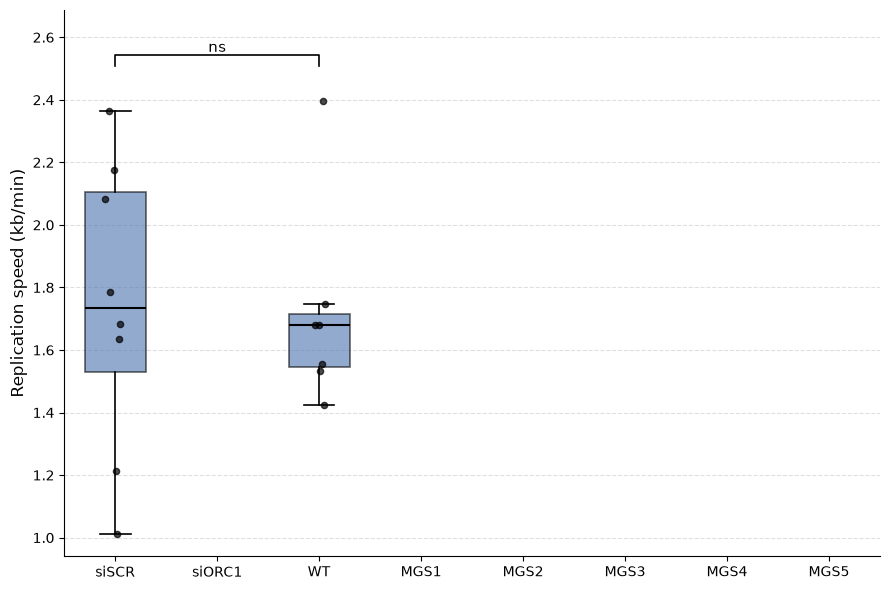

In [80]:
# -------------------------------------------------------
# Create figure
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))
    
# -------------------------------------------------------
# Draw boxplot
# -------------------------------------------------------

bp = plt.boxplot(
    groups,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
    medianprops={
        "color": "black",
        "linewidth": 1.5,
    },
    whiskerprops={
        "color": "black",
        "linewidth": 1.2,
    },
    capprops={
        "color": "black",
        "linewidth": 1.2,
    },
)

for box in bp["boxes"]:
    box.set(
        facecolor="#4C72B0",
        alpha=0.6,
        edgecolor="black",
        linewidth=1.2,
    )

# -------------------------------------------------------
# Add jittered individual values
# -------------------------------------------------------
rng = np.random.default_rng(seed=42)

for position, values in enumerate(groups, start=1):
    x_jitter = rng.normal(
        loc=position,
        scale=0.05,
        size=len(values),
    )

    ax.scatter(
        x_jitter,
        values,
        s=20,
        color="black",
        alpha=0.7,
        zorder=3,
    )

# -------------------------------------------------------
# Add significance brackets
# -------------------------------------------------------
sample_positions = {
    sample: position
    for position, sample in enumerate(sample_order, start=1)
}

data_min = data_plot[var].min()
data_max = data_plot[var].max()
data_range = data_max - data_min

if data_range == 0:
    data_range = 1

bracket_height = data_range * 0.025
bracket_step = data_range * 0.10
current_y = data_max + data_range * 0.08

# Sort comparisons by distance between groups.
# Shorter brackets are drawn first.
stats_plot["span"] = stats_plot.apply(
    lambda row: abs(
        sample_positions[row["Group_2"]]
        - sample_positions[row["Group_1"]]
    ),
    axis=1,
)

stats_plot = stats_plot.sort_values("span")


for _, row in stats_plot.iterrows():
    group1 = row["Group_1"]
    group2 = row["Group_2"]
    p_value = row["p-value"]

    x1 = sample_positions[group1]
    x2 = sample_positions[group2]

    add_bracket(
        ax=ax,
        x1=x1,
        x2=x2,
        y=current_y,
        height=bracket_height,
        text=p_to_stars(p_value),
    )

    current_y += bracket_step

# -------------------------------------------------------
# Format axes
# -------------------------------------------------------
ax.set_ylabel(y_axis, fontsize=12)
ax.set_xlabel("")

ax.set_xticks(range(1, len(sample_order) + 1))
ax.set_xticklabels(sample_order)

plt.grid(axis="y", linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

bottom_limit = data_min - data_range * 0.05
top_limit = current_y + bracket_step * 0.3
ax.set_ylim(
    bottom=bottom_limit,
    top=top_limit,
)

plt.tight_layout()

# -------------------------------------------------------
# Save figure
# -------------------------------------------------------
output_file = f"{OUTPUT_DIR}/{save_name}"

fig.savefig(
    output_file,
    dpi=600,
    bbox_inches="tight",
)

print(f"Plot saved to: {output_file}")

plt.show()

### *Optional code*

In [ ]:
# -------------------------------------------------------
# t-test data analysis
# -------------------------------------------------------

# Data
# data_plot = iod_kb
# var = "IOD_kb"

# wt = data_plot.loc[
    # data_plot["Sample_name"] == "WT",
    # var
# ].dropna()

# results = []

# for sample in ["siSCR", "siORC1", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]:

    # mutant = data_plot.loc[
        # data_plot["Sample_name"] == sample,
        # var
    # ].dropna()

    # stat, p = ttest_ind(
        # wt,
        # mutant,
        # equal_var=False,   # Welch's t-test (recommended)
    # )

    # results.append({
        # "Comparison": f"WT vs {sample}",
        # "WT_n": len(wt),
        # "Sample_n": len(mutant),
        # "U": stat,
        # "p-value": p,
    # })

# stats_t_df = pd.DataFrame(results)

# print(stats_t_df)

In [ ]:
# -------------------------------------------------------
# Boxplot without statistical brackets
# -------------------------------------------------------

# plt.figure(figsize=(7, 5))

# Variables
# data_plot = iod_kb
# var = "IOD_kb"

# Order of groups (optional)
# sample_order = ["siSCR", "siORC1", "WT", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]

# groups = []
# labels = []

# for sample in sample_order:
        # values = data_plot.loc[
        # data_plot["Sample_name"] == sample,
        # var
    # ]
        
        # groups.append(values)
        # labels.append(sample)

    

# bp = plt.boxplot(
    # groups,
    # patch_artist=True,
    # showfliers=False,
    # widths=0.6,
# )

# for box in bp["boxes"]:
    # box.set(facecolor="#4C72B0", alpha=0.6)

# Jittered dots
# for i, values in enumerate(groups, start=1):
    # x = np.random.normal(i, 0.05, len(values))
    # plt.scatter(x, values, s=20, color="black", alpha=0.7, zorder=3)

# plt.ylabel("iod_kb")
# plt.xticks(range(1, len(labels) + 1), labels)
# plt.grid(axis="y", linestyle="--", alpha=0.4)

# plt.tight_layout()
# plt.savefig(f"{OUTPUT_DIR}/iod_boxplot.png", dpi=600, bbox_inches="tight")
# print(f"Plot is saved in the directory: {OUTPUT_DIR}")

# plt.show()